# Working with complicated dataset

Your name: Ronald Celino

### Question 1

blast_results: https://raw.githubusercontent.com/csbfx/advpy122-data/master/blast_results.csv

Read in the data from the csv file above. Skip all the comment lines, create a header for the dataframe based on the fields list in the comment line that starts with **# Fields:**. Drop the first column `query acc.ver`. Set the `subject acc.ver` as the index of the dataframe. The last column of the dataframe should be `publications`. Show the first five rows of the resulting dataframe.

In [123]:
### Your code here . . .
import urllib.request
import pandas as pd

blast_file = "https://raw.githubusercontent.com/csbfx/advpy122-data/master/blast_results.csv"

blast = pd.read_csv(blast_file)
with urllib.request.urlopen(blast_file) as f:
  for i in range(15):
      line = f.readline().decode('utf-8').strip()
      print(f"{i + 1}: {line}")

1: # blastp,,,,,,,,,,,,,,,
2: # Iteration: 0,,,,,,,,,,,,,,,
3: # Query: YP_220550.1 NADH dehydrogenase subunit 1 (mitochondrion) [Mus musculus domesticus],,,,,,,,,,,,,,,
4: # RID: 9SW3UNUT015,,,,,,,,,,,,,,,
5: # Database: nr,,,,,,,,,,,,,,,
6: "# Fields: query acc.ver, subject acc.ver, % identity, alignment length, mismatches, gap opens, q. start, q. end, s. start, s. end, evalue, bit score, % positives, bonds, publications",,,,,,,,,,,,,,,
7: # 100 hits found,,,,,,,,,,,,,,,
8: YP_220550.1,NP_904328.1,100,318,0,0,1,318,1,318,0,629,100," 1,487 ",9,
9: YP_220550.1,AGK29621.1,99.686,318,1,0,1,318,1,318,0,629,100," 17,947 ",47,
10: YP_220550.1,YP_220563.1,99.686,318,1,0,1,318,1,318,0,627,100," 12,106 ",13,
11: YP_220550.1,ACM24502.1,99.686,318,1,0,1,318,1,318,0,627,99.69," 2,319 ",41,
12: YP_220550.1,AHG32084.1,99.371,318,2,0,1,318,1,318,0,627,100," 18,964 ",3,
13: YP_220550.1,AEN03421.1,99.686,318,1,0,1,318,1,318,0,626,99.69," 12,444 ",39,
14: YP_220550.1,6G2J_H,100,317,0,0,2,318,2,318,0,62

In [124]:
# read in and skip rows, no header
blast = pd.read_csv(blast_file,
                    na_values=['-'],
                    skiprows=7,
                    header=None
                    )
blast.head()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15
0,YP_220550.1,NP_904328.1,100.000,318,0,0,1,318,1,318,0,629,100.00,"1,487",9.0,NaN
1,YP_220550.1,AGK29621.1,99.686,318,1,0,1,318,1,318,0,629,100.00,"17,947",47.0,NaN
2,YP_220550.1,YP_220563.1,99.686,318,1,0,1,318,1,318,0,627,100.00,"12,106",13.0,NaN
3,YP_220550.1,ACM24502.1,99.686,318,1,0,1,318,1,318,0,627,99.69,"2,319",41.0,NaN
4,YP_220550.1,AHG32084.1,99.371,318,2,0,1,318,1,318,0,627,100.00,"18,964",3.0,NaN


In [125]:
# creating my own column names for data
columns = ["Query AV", "Subject AV", "% Identity", "Alignment Length",
           "Mismatches", "Gap Opens", "q.start",
           "q.end", "s.start", "s.end", "evalue", "bit score",
           "% positives", "Bonds", "Publications"]

blast = pd.read_csv(blast_file,
                    na_values=['-'],
                    skiprows=7,
                    header=None,
                    names=columns,
                    usecols=columns,
                    thousands=","
                    )
blast.head()

,Query AV,Subject AV,% Identity,Alignment Length,Mismatches,Gap Opens,q.start,q.end,s.start,s.end,evalue,bit score,% positives,Bonds,Publications
0,YP_220550.1,NP_904328.1,100.000,318,0,0,1,318,1,318,0,629,100.00,1487,9.0
1,YP_220550.1,AGK29621.1,99.686,318,1,0,1,318,1,318,0,629,100.00,17947,47.0
2,YP_220550.1,YP_220563.1,99.686,318,1,0,1,318,1,318,0,627,100.00,12106,13.0
3,YP_220550.1,ACM24502.1,99.686,318,1,0,1,318,1,318,0,627,99.69,2319,41.0
4,YP_220550.1,AHG32084.1,99.371,318,2,0,1,318,1,318,0,627,100.00,18964,3.0


In [126]:
# dropping first column query acc.ver & set index to subject acc.ver
blast.drop(columns=["Query AV"], inplace=True)
blast.set_index("Subject AV", inplace=True)

# first 5 rows of resulting dataframe!
blast.head()

,% Identity,Alignment Length,Mismatches,Gap Opens,q.start,q.end,s.start,s.end,evalue,bit score,% positives,Bonds,Publications
Subject AV,,,,,,,,,,,,,
NP_904328.1,100.000,318,0,0,1,318,1,318,0,629,100.00,1487,9.0
AGK29621.1,99.686,318,1,0,1,318,1,318,0,629,100.00,17947,47.0
YP_220563.1,99.686,318,1,0,1,318,1,318,0,627,100.00,12106,13.0
ACM24502.1,99.686,318,1,0,1,318,1,318,0,627,99.69,2319,41.0
AHG32084.1,99.371,318,2,0,1,318,1,318,0,627,100.00,18964,3.0


In [127]:
blast.info()

<class 'pandas.core.frame.DataFrame'>
Index: 100 entries, NP_904328.1 to AGS12808.1
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   % Identity        100 non-null    float64
 1   Alignment Length  100 non-null    int64  
 2   Mismatches        100 non-null    int64  
 3   Gap Opens         100 non-null    int64  
 4   q.start           100 non-null    int64  
 5   q.end             100 non-null    int64  
 6   s.start           100 non-null    int64  
 7   s.end             100 non-null    int64  
 8   evalue            100 non-null    int64  
 9   bit score         100 non-null    int64  
 10  % positives       100 non-null    float64
 11  Bonds             100 non-null    int64  
 12  Publications      97 non-null     float64
dtypes: float64(3), int64(10)
memory usage: 10.9+ KB


### Question 2
What is the average number of publications?

In [128]:
### Your code here . . .
avg_publications = blast["Publications"].mean()

print("The average number of publications is ", {avg_publications})

The average number of publications is  {np.float64(26.989690721649485)}


### Question 3
List the `subject acc.ver` that has over 15,000 bonds.

In [129]:
### Your code here . . .
# shows indices that appear because subject acc.ver
# was set to index
blast[blast["Bonds"] > 15000].index

Index(['AGK29621.1', 'AHG32084.1', '6G2J_H', 'YP_002791042.1', 'AGK29634.1',
       '0806162F', 'YP_009112408.1', 'YP_001876469.1', 'YP_009092269.1',
       'AHG32149.1', 'YP_009092074.1', 'YP_009450474.1', 'YP_004123270.1',
       'YP_009092073.1', 'AHZ60901.1', 'YP_004123350.1', 'YP_009453754.1',
       'ADD46492.1', 'YP_007025968.1', 'YP_009453806.1', 'YP_007024956.1',
       'ASM92364.1', 'YP_006073044.1', 'ASM92494.1', 'ADG95699.1',
       'YP_004891275.1', 'YP_009166014.1', 'YP_009538416.1', 'YP_009414182.1',
       'YP_009178854.1', 'YP_009414415.1', 'YP_009353908.1', 'YP_009093743.1',
       'ABX45285.1', 'YP_009414156.1', 'YP_009414363.1'],
      dtype='object', name='Subject AV')

### Question 4
Create a plot that shows the correlation between `% identity` and `% positives`.

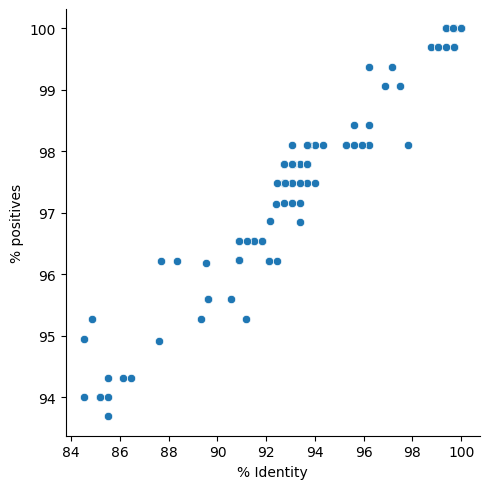

In [130]:
### Your code here . . .
import matplotlib.pyplot as plt
import seaborn as sns

# plot
plot = sns.relplot(data=blast, x="% Identity", y="% positives", kind="scatter")
plt.show()

### Question  5
Add a column `Protein source` to the dataframe from Question 1 based on the data in this csv file: https://raw.githubusercontent.com/csbfx/advpy122-data/master/protein_source.csv. Merge the data when the `subject acc.ver` from the dataframe equals to `Protein` in the csv file. Entries without a matching protein will have `NA` as `Protein source`.

In [131]:
### Your code here . . .
protein_src = pd.read_csv("https://raw.githubusercontent.com/csbfx/advpy122-data/master/protein_source.csv")
protein_src.head()

,Unnamed: 0,Protein,Source
0,0,NP_904328.1,RefSeq
1,2,YP_220563.1,GenPept
2,12,YP_002791042.1,GenPept
3,13,YP_001686698.1,GenPept
4,21,YP_009112408.1,GenPept


In [132]:
### Your code here . . .
# reset the index to turn 'Subject AV' back into a column
blast_reset = blast.reset_index()

# merge the dataframes using the 'Subject AV' column from blast_reset
# and the 'Protein' column from protein_src
merged_blast = blast_reset.merge(protein_src,
                                 left_on='Subject AV',
                                 right_on='Protein',
                                 how='left')

# drop unneeded columns from the new merged dataframe
merged_blast.drop(columns=['Unnamed: 0', 'Protein'], inplace=True)

# rename source col to protein source and set subject acc.ver back to the index
merged_blast.rename(columns={'Source': 'Protein source'}, inplace=True)
merged_blast.set_index('Subject AV', inplace=True)

# update the original blast DataFrame with merged results
blast = merged_blast
blast.head()

,% Identity,Alignment Length,Mismatches,Gap Opens,q.start,q.end,s.start,s.end,evalue,bit score,% positives,Bonds,Publications,Protein source
Subject AV,,,,,,,,,,,,,,
NP_904328.1,100.000,318,0,0,1,318,1,318,0,629,100.00,1487,9.0,RefSeq
AGK29621.1,99.686,318,1,0,1,318,1,318,0,629,100.00,17947,47.0,NaN
YP_220563.1,99.686,318,1,0,1,318,1,318,0,627,100.00,12106,13.0,GenPept
ACM24502.1,99.686,318,1,0,1,318,1,318,0,627,99.69,2319,41.0,NaN
AHG32084.1,99.371,318,2,0,1,318,1,318,0,627,100.00,18964,3.0,NaN
